# Phase 0: JW Baroclinic Wave Baseline

Verifies that vanilla MPAS-A builds and runs inside the container.
The Jablonowski-Williamson baroclinic wave test on the 480-km mesh
(2,562 cells, 26 vertical levels, 1-day simulation) is our baseline
for all subsequent CheMPAS-A phases.

**Pre-requisite:** Run the container build and JW test first (see `verification/README.md`).
The notebook reads `data/jw_480km_chapman/output.nc` produced by that run.

In [2]:
import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("..") / "data" / "jw_480km_chapman"
OUTPUT = DATA_DIR / "output.nc"
assert OUTPUT.exists(), f"Run the JW test first — {OUTPUT} not found"

ds = nc.Dataset(OUTPUT)
lat = np.degrees(ds["latCell"][:])
lon = np.degrees(ds["lonCell"][:])
nTimes = ds.dimensions["Time"].size
nLevels = ds.dimensions["nVertLevels"].size
print(f"Grid: {ds.dimensions['nCells'].size} cells, {nLevels} levels, {nTimes} time steps")
print(f"MPAS version: {ds.getncattr('version')}")
print(f"Run duration: {ds.getncattr('config_run_duration')}")

Grid: 2562 cells, 26 levels, 25 time steps
MPAS version: 8.3.1
Run duration: 1_00:00:00


## 1. Zonal Wind at Mid-Level (500 hPa)

The JW test initializes a mid-latitude jet. This plot shows the zonal wind
at approximately 500 hPa (level index 6) at the initial and final time steps.

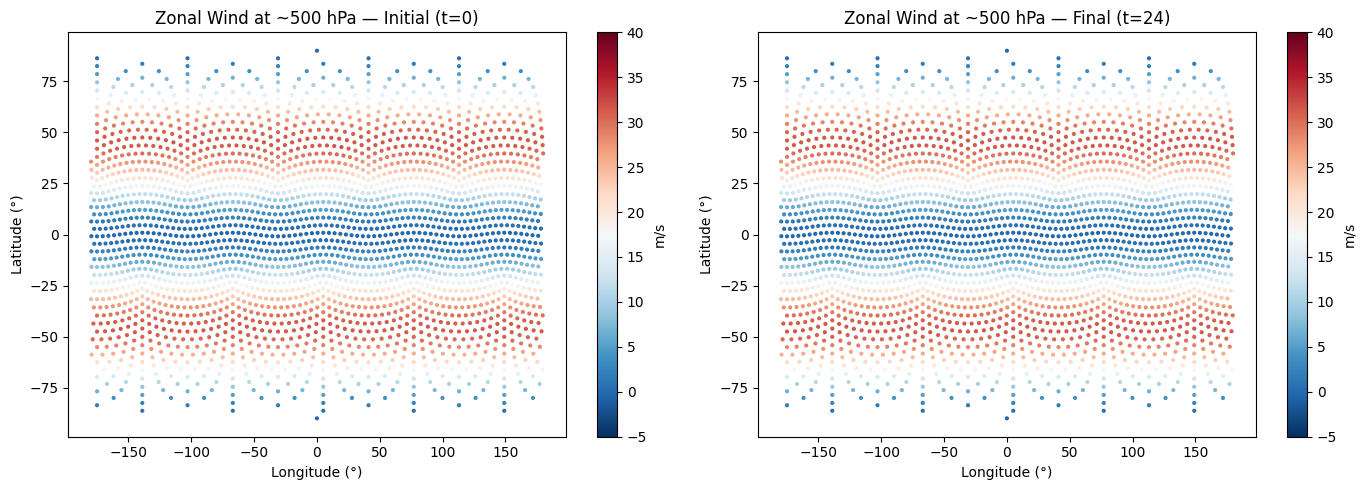

In [3]:
lev = 6  # ~514 hPa

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, t, label in zip(axes, [0, -1], ["Initial (t=0)", f"Final (t={nTimes-1})"]):
    u = ds["uReconstructZonal"][t, :, lev]
    sc = ax.scatter(lon, lat, c=u, s=4, cmap="RdBu_r", vmin=-5, vmax=40)
    ax.set_xlabel("Longitude (°)")
    ax.set_ylabel("Latitude (°)")
    ax.set_title(f"Zonal Wind at ~500 hPa — {label}")
    plt.colorbar(sc, ax=ax, label="m/s")
plt.tight_layout()
plt.show()

## 2. Potential Temperature Cross-Section

Latitude–height cross-section of potential temperature at the final time step,
averaged over all longitudes. Shows the expected tropospheric lapse rate and
stratospheric inversion.

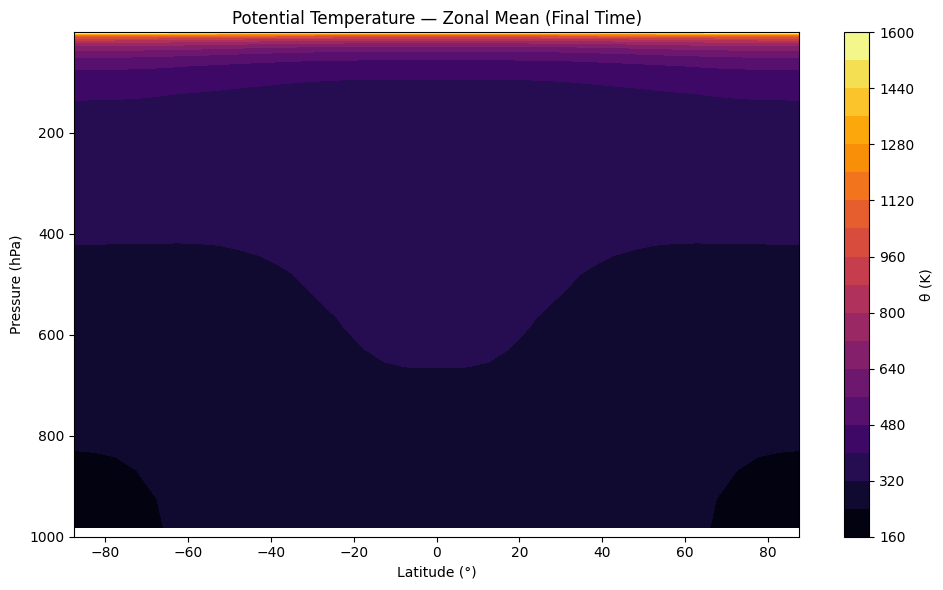

In [4]:
# Compute pressure at each level (base + perturbation) for vertical coordinate
p_base = ds["pressure_base"][-1, :, :]  # (nCells, nLevels)
p_pert = ds["pressure_p"][-1, :, :]
pressure = (p_base + p_pert) / 100.0  # hPa
theta = ds["theta"][-1, :, :]  # (nCells, nLevels)

# Bin by latitude (5° bins)
lat_bins = np.arange(-90, 91, 5)
lat_centers = 0.5 * (lat_bins[:-1] + lat_bins[1:])
theta_binned = np.zeros((len(lat_centers), nLevels))
p_binned = np.zeros((len(lat_centers), nLevels))

for i in range(len(lat_centers)):
    mask = (lat >= lat_bins[i]) & (lat < lat_bins[i+1])
    if mask.sum() > 0:
        theta_binned[i, :] = theta[mask, :].mean(axis=0)
        p_binned[i, :] = pressure[mask, :].mean(axis=0)

fig, ax = plt.subplots(figsize=(10, 6))
cf = ax.contourf(lat_centers, p_binned.mean(axis=0), theta_binned.T,
                 levels=20, cmap="inferno")
ax.set_ylim(1000, 1)
ax.set_ylabel("Pressure (hPa)")
ax.set_xlabel("Latitude (°)")
ax.set_title("Potential Temperature — Zonal Mean (Final Time)")
plt.colorbar(cf, ax=ax, label="θ (K)")
plt.tight_layout()
plt.show()

## 3. Surface Pressure Map

Surface pressure at initial and final time. For a 1-day JW test at 480 km,
the baroclinic wave hasn't fully developed, so we expect a nearly uniform
field (~1000 hPa everywhere). Any large deviations indicate a problem.

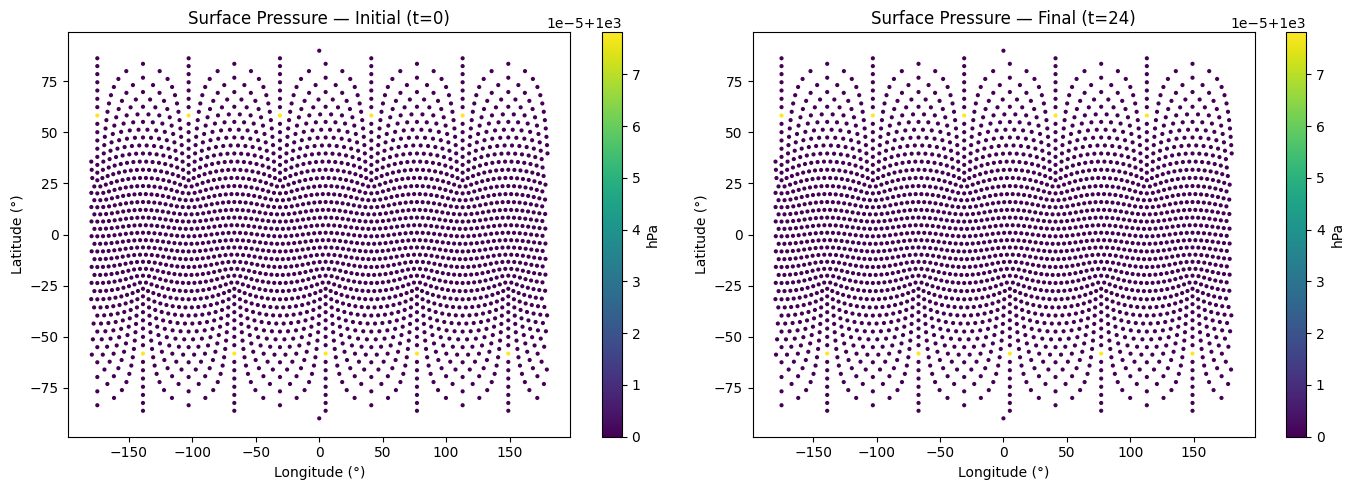

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, t, label in zip(axes, [0, -1], ["Initial (t=0)", f"Final (t={nTimes-1})"]):
    sp = ds["surface_pressure"][t, :] / 100.0  # hPa
    sc = ax.scatter(lon, lat, c=sp, s=4, cmap="viridis")
    ax.set_xlabel("Longitude (°)")
    ax.set_ylabel("Latitude (°)")
    ax.set_title(f"Surface Pressure — {label}")
    plt.colorbar(sc, ax=ax, label="hPa")
plt.tight_layout()
plt.show()

## 4. Meridional Wind at Mid-Level

Meridional wind is initialized to zero in JW. Any growth over the simulation
shows the baroclinic instability developing.

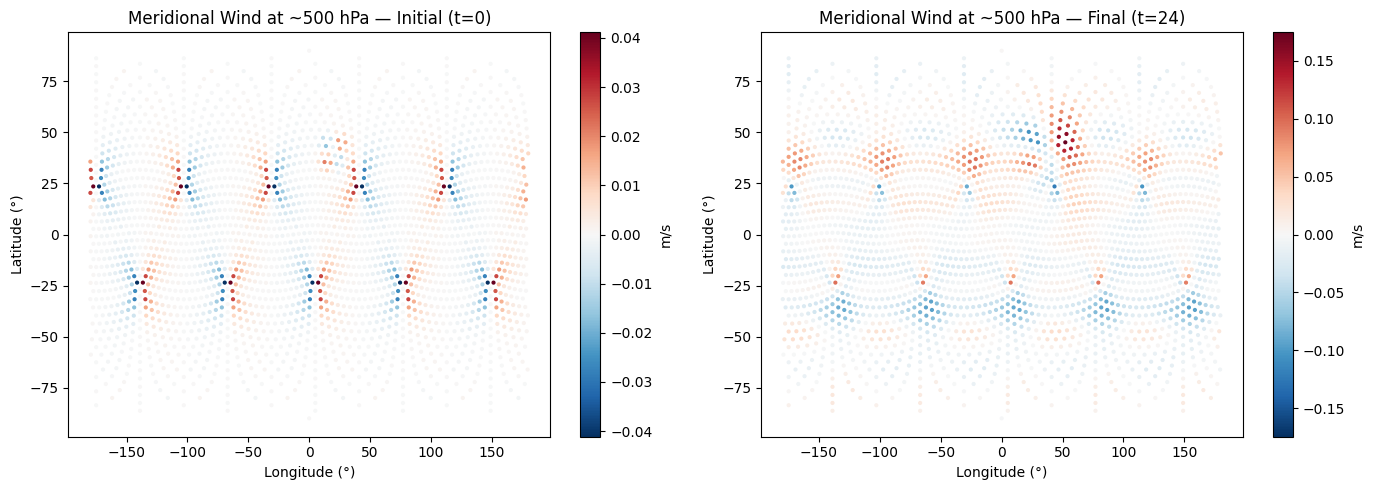

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, t, label in zip(axes, [0, -1], ["Initial (t=0)", f"Final (t={nTimes-1})"]):
    v = ds["uReconstructMeridional"][t, :, lev]
    vmax = max(abs(v.min()), abs(v.max()), 0.01)
    sc = ax.scatter(lon, lat, c=v, s=4, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_xlabel("Longitude (°)")
    ax.set_ylabel("Latitude (°)")
    ax.set_title(f"Meridional Wind at ~500 hPa — {label}")
    plt.colorbar(sc, ax=ax, label="m/s")
plt.tight_layout()
plt.show()

## 5. Vertical Profiles

Vertical profiles of pressure, potential temperature, and zonal wind at a
sample mid-latitude cell. Validates the vertical coordinate and basic state.

Sample cell 415: lat=45.1°, lon=-163.7°


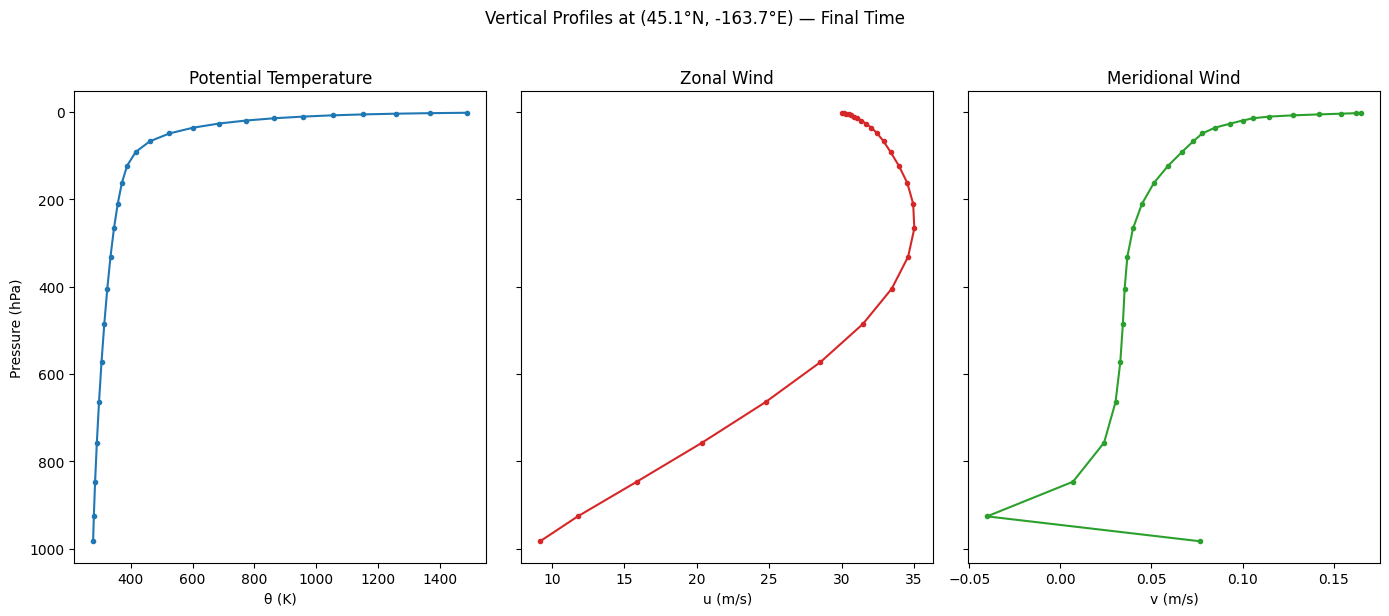

In [7]:
# Pick a mid-latitude cell (~45°N)
i_cell = np.argmin(np.abs(lat - 45.0))
print(f"Sample cell {i_cell}: lat={lat[i_cell]:.1f}°, lon={lon[i_cell]:.1f}°")

p_prof = (ds["pressure_base"][-1, i_cell, :] + ds["pressure_p"][-1, i_cell, :]) / 100.0
theta_prof = ds["theta"][-1, i_cell, :]
u_prof = ds["uReconstructZonal"][-1, i_cell, :]

fig, axes = plt.subplots(1, 3, figsize=(14, 6), sharey=True)

axes[0].plot(theta_prof, p_prof, "o-", markersize=3)
axes[0].set_xlabel("θ (K)")
axes[0].set_ylabel("Pressure (hPa)")
axes[0].set_title("Potential Temperature")
axes[0].invert_yaxis()

axes[1].plot(u_prof, p_prof, "o-", markersize=3, color="tab:red")
axes[1].set_xlabel("u (m/s)")
axes[1].set_title("Zonal Wind")

v_prof = ds["uReconstructMeridional"][-1, i_cell, :]
axes[2].plot(v_prof, p_prof, "o-", markersize=3, color="tab:green")
axes[2].set_xlabel("v (m/s)")
axes[2].set_title("Meridional Wind")

fig.suptitle(f"Vertical Profiles at ({lat[i_cell]:.1f}°N, {lon[i_cell]:.1f}°E) — Final Time", y=1.02)
plt.tight_layout()
plt.show()

## 6. Time Evolution

Global statistics over time. Kinetic energy growth indicates the baroclinic
instability developing. Potential temperature should remain bounded.

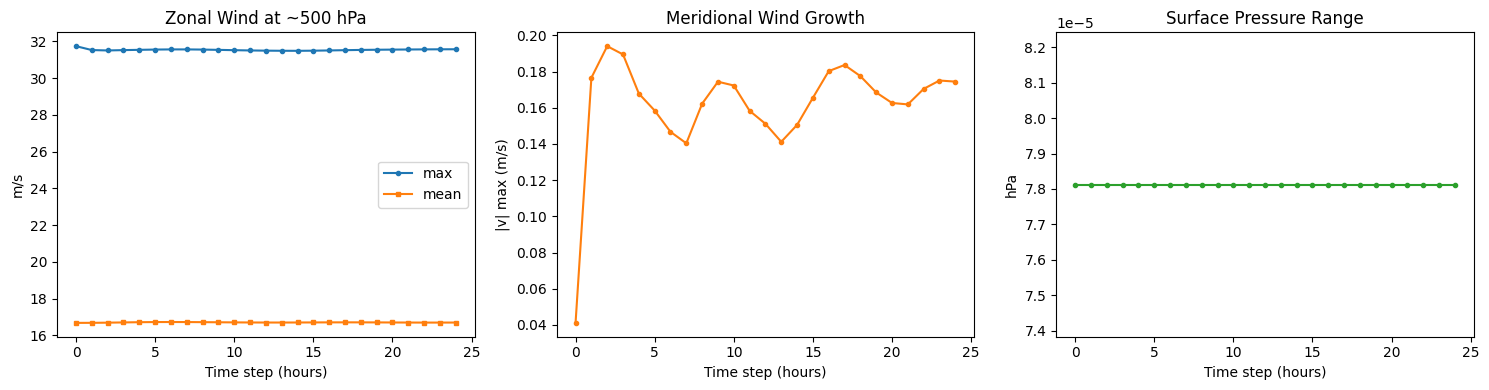

In [8]:
times = np.arange(nTimes)

# Global mean and max zonal wind over time
u_max = np.array([ds["uReconstructZonal"][t, :, lev].max() for t in range(nTimes)])
u_mean = np.array([ds["uReconstructZonal"][t, :, lev].mean() for t in range(nTimes)])
v_max = np.array([np.abs(ds["uReconstructMeridional"][t, :, lev]).max() for t in range(nTimes)])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(times, u_max, "o-", label="max", markersize=3)
axes[0].plot(times, u_mean, "s-", label="mean", markersize=3)
axes[0].set_xlabel("Time step (hours)")
axes[0].set_ylabel("m/s")
axes[0].set_title("Zonal Wind at ~500 hPa")
axes[0].legend()

axes[1].plot(times, v_max, "o-", markersize=3, color="tab:orange")
axes[1].set_xlabel("Time step (hours)")
axes[1].set_ylabel("|v| max (m/s)")
axes[1].set_title("Meridional Wind Growth")

sp_range = np.array([
    (ds["surface_pressure"][t, :].max() - ds["surface_pressure"][t, :].min())
    for t in range(nTimes)
])
axes[2].plot(times, sp_range / 100.0, "o-", markersize=3, color="tab:green")
axes[2].set_xlabel("Time step (hours)")
axes[2].set_ylabel("hPa")
axes[2].set_title("Surface Pressure Range")

plt.tight_layout()
plt.show()

## Summary

**Phase 0 is PASSED if:**
- The JW test ran to completion (output.nc exists with 25 time steps)
- Zonal wind shows the expected mid-latitude jet (~35 m/s)
- Potential temperature shows tropospheric lapse + stratospheric inversion
- Surface pressure is approximately uniform (~1000 hPa)
- No NaN or extreme values in any field

In [9]:
# Automated checks
checks = []

# Check 1: Correct number of time steps
checks.append(("Time steps == 25", nTimes == 25))

# Check 2: No NaN values
has_nan = False
for v in ["surface_pressure", "theta", "uReconstructZonal", "uReconstructMeridional"]:
    if np.isnan(ds[v][:]).any():
        has_nan = True
checks.append(("No NaN values", not has_nan))

# Check 3: Jet stream present (~25-40 m/s)
u_max_val = ds["uReconstructZonal"][:].max()
checks.append((f"Jet stream present (max u = {u_max_val:.1f} m/s)", 20 < u_max_val < 50))

# Check 4: Surface pressure near 1000 hPa
sp_mean = ds["surface_pressure"][:].mean() / 100.0
checks.append((f"Surface pressure ~ 1000 hPa (mean = {sp_mean:.1f})", 990 < sp_mean < 1010))

# Check 5: Theta physically reasonable (200-800 K)
theta_min = ds["theta"][:].min()
theta_max = ds["theta"][:].max()
checks.append((f"θ in range (min={theta_min:.0f}, max={theta_max:.0f} K)",
               200 < theta_min and theta_max < 2000))

print("=" * 60)
all_pass = True
for label, ok in checks:
    status = "PASS" if ok else "FAIL"
    if not ok:
        all_pass = False
    print(f"  [{status}] {label}")
print("=" * 60)
print(f"  Phase 0: {'PASSED' if all_pass else 'FAILED'}")
print("=" * 60)

ds.close()

  [PASS] Time steps == 25
  [PASS] No NaN values
  [PASS] Jet stream present (max u = 35.4 m/s)
  [PASS] Surface pressure ~ 1000 hPa (mean = 1000.0)
  [PASS] θ in range (min=227, max=1537 K)
  Phase 0: PASSED
